In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [8]:
# ============================================================
# Загрузка quarterly_data для проверки товаров Гиффена
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

try:
    from google.colab import drive
    drive.mount("/content/gdrive")
except Exception:
    pass

BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

possible_paths = [
    BASE_DIR / "demand_forecast_2025" / "quarterly_dataset_with_demand_proxy.csv",
    BASE_DIR / "quarterly_model_selection_staged" / "quarterly_model_dataset_with_demand_proxy.csv",
    BASE_DIR / "quarterly_model_selection_staged" / "quarterly_model_dataset_enriched_fixed.csv",
    BASE_DIR / "quarterly_model_selection_staged" / "quarterly_model_dataset_enriched.csv",
    BASE_DIR / "quarterly_model_selection_staged" / "quarterly_model_dataset.csv",
]

DATASET_PATH = None

for path in possible_paths:
    if path.exists():
        DATASET_PATH = path
        break

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Не найден готовый квартальный датасет. "
        "Сначала запусти notebook, который создаёт quarterly_model_dataset_enriched_fixed.csv "
        "или quarterly_dataset_with_demand_proxy.csv."
    )

quarterly_data = pd.read_csv(DATASET_PATH, parse_dates=["period_end"])
quarterly_data["period_end"] = pd.to_datetime(quarterly_data["period_end"]).dt.normalize()

quarterly_data = quarterly_data.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

print("Загружен датасет:", DATASET_PATH)
print("Размер:", quarterly_data.shape)

display(quarterly_data.head())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Загружен датасет: /content/gdrive/MyDrive/rostat/demand_forecast_2025/quarterly_dataset_with_demand_proxy.csv
Размер: (360, 75)


,product_group_code,product_group_name,period_end,year,quarter,mean_price,median_price,n_price_products,n_price_observations,sales_quarter_thousand_rub,...,real_sales_proxy_filled,real_sales_proxy_index_filled,q_observed_proxy,normal_stock_days,stock_shortage,demand_proxy_raw,demand_proxy_index,demand_proxy_index_lag1,demand_proxy_index_lag2,demand_proxy_index_lag4
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-03-31,2016,1,65.201042,65.570,8.0,96.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,G01,"Хлеб, крупы, мука и макаронные изделия",2016-06-30,2016,2,67.253462,66.090,8.0,104.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,G01,"Хлеб, крупы, мука и макаронные изделия",2016-09-30,2016,3,68.782788,66.115,8.0,104.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,G01,"Хлеб, крупы, мука и макаронные изделия",2016-12-31,2016,4,68.152308,65.675,8.0,104.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2017,1,67.500104,65.115,8.0,96.0,2.617199e+08,...,100.698764,100.0,100.0,NaN,NaN,100.0,100.0,NaN,NaN,NaN


In [10]:
# ============================================================
# Проверка и восстановление нужных колонок для Giffen test
# ============================================================

def make_index_from_first_valid(x):
    x = x.astype(float)
    valid = x.dropna()
    if len(valid) == 0:
        return pd.Series(np.nan, index=x.index)

    base = valid.iloc[0]

    if pd.isna(base) or base == 0:
        return pd.Series(np.nan, index=x.index)

    return x / base * 100


required_cols = [
    "product_group_code",
    "product_group_name",
    "period_end",
    "year",
    "quarter",
    "sales_index",
    "price_index",
]

missing_cols = [c for c in required_cols if c not in quarterly_data.columns]

if missing_cols:
    raise ValueError(f"В датасете нет обязательных колонок: {missing_cols}")


# Заполненный индекс цен, чтобы закрыть 2021 год
if "price_index_filled" not in quarterly_data.columns:
    quarterly_data["price_index_filled"] = (
        quarterly_data
        .groupby("product_group_code")["price_index"]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )


# Наблюдаемый физический proxy-объём:
# sales_index / price_index_filled
if "real_sales_proxy_index_filled" not in quarterly_data.columns:
    quarterly_data["real_sales_proxy_filled"] = (
        quarterly_data["sales_index"] / quarterly_data["price_index_filled"] * 100
    )

    quarterly_data["real_sales_proxy_index_filled"] = (
        quarterly_data
        .groupby("product_group_code")["real_sales_proxy_filled"]
        .transform(make_index_from_first_valid)
    )


# Event-флаги
if "shock_2022_q1" not in quarterly_data.columns:
    quarterly_data["shock_2022_q1"] = (
        (quarterly_data["year"] == 2022) &
        (quarterly_data["quarter"] == 1)
    ).astype(int)

if "shock_2022_q2" not in quarterly_data.columns:
    quarterly_data["shock_2022_q2"] = (
        (quarterly_data["year"] == 2022) &
        (quarterly_data["quarter"] == 2)
    ).astype(int)

if "shock_2022_h2" not in quarterly_data.columns:
    quarterly_data["shock_2022_h2"] = (
        (quarterly_data["year"] == 2022) &
        (quarterly_data["quarter"].isin([3, 4]))
    ).astype(int)

if "post_2022" not in quarterly_data.columns:
    quarterly_data["post_2022"] = (
        quarterly_data["period_end"] >= pd.Timestamp("2022-03-31")
    ).astype(int)


print("quarterly_data готов для проверки товаров Гиффена")
print("Колонки:", quarterly_data.columns.tolist())

quarterly_data готов для проверки товаров Гиффена
Колонки: ['product_group_code', 'product_group_name', 'period_end', 'year', 'quarter', 'mean_price', 'median_price', 'n_price_products', 'n_price_observations', 'sales_quarter_thousand_rub', 'sales_cumulative_thousand_rub', 'n_sales_products', 'sales_is_observed', 'price_index', 'sales_index', 'price_index_lag1', 'price_index_lag4', 'price_growth_qoq', 'price_growth_yoy', 'price_growth_qoq_lag1', 'price_growth_yoy_lag1', 'quarter_sin', 'quarter_cos', 'stock_days_mean', 'stock_days_last', 'stock_months_available', 'stock_days_mean_lag1', 'stock_days_mean_lag2', 'stock_days_last_lag1', 'stock_days_qoq', 'stock_days_yoy', 'stock_days_qoq_lag1', 'stock_days_yoy_lag1', 'ppi_group_index', 'ppi_group_mom_q_compounded', 'n_ppi_products', 'ppi_group_index_lag1', 'ppi_group_index_lag2', 'ppi_group_index_lag4', 'ppi_group_mom_q_compounded_lag1', 'ppi_group_mom_q_compounded_lag2', 'ppi_group_mom_q_compounded_lag4', 'ppi_growth_qoq', 'ppi_growth_yoy

In [11]:
# ============================================================
# Проверка категорий на Гиффеноподобное поведение
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

OUT_DIR = Path("/content/drive/MyDrive/rostat/demand_forecast_2025")
GIFFEN_DIR = OUT_DIR / "giffen_test"
GIFFEN_DIR.mkdir(parents=True, exist_ok=True)

# Товарные группы. G11 исключаем, потому что это услуги.
# G10 можно добавить отдельно, если хочешь тестировать топливо.
GIFFEN_TEST_GROUPS = ["G01", "G02", "G03", "G04", "G05", "G07", "G99"]

ALPHA = 0.10  # уровень значимости: 10%, можно заменить на 0.05

# ------------------------------------------------------------
# 1. Подготовка переменных
# ------------------------------------------------------------

df = quarterly_data[
    quarterly_data["product_group_code"].isin(GIFFEN_TEST_GROUPS)
].copy()

df = df.sort_values(["product_group_code", "period_end"]).reset_index(drop=True)

# Если real_sales_proxy_index_filled ещё не создан, создаём его.
if "real_sales_proxy_index_filled" not in df.columns:
    if "price_index_filled" not in df.columns:
        df["price_index_filled"] = (
            df
            .groupby("product_group_code")["price_index"]
            .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
        )

    df["real_sales_proxy_filled"] = (
        df["sales_index"] / df["price_index_filled"] * 100
    )

    def make_index_from_first_valid(x):
        x = x.astype(float)
        valid = x.dropna()
        if len(valid) == 0:
            return pd.Series(np.nan, index=x.index)
        base = valid.iloc[0]
        if pd.isna(base) or base == 0:
            return pd.Series(np.nan, index=x.index)
        return x / base * 100

    df["real_sales_proxy_index_filled"] = (
        df
        .groupby("product_group_code")["real_sales_proxy_filled"]
        .transform(make_index_from_first_valid)
    )

# Основная зависимая переменная для теста:
# наблюдаемый физический proxy объём, а не уже скорректированный спрос.
df["q_obs_proxy"] = df["real_sales_proxy_index_filled"]

# Цена
if "price_index_filled" not in df.columns:
    df["price_index_filled"] = (
        df
        .groupby("product_group_code")["price_index"]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )

df["log_q"] = np.log(df["q_obs_proxy"].clip(lower=1e-6))
df["log_price"] = np.log((df["price_index_filled"] / 100).clip(lower=1e-6))

# Тренд
df["time_idx"] = df.groupby("product_group_code").cumcount()

# Дефицит запасов, если есть stock_days_mean
if "stock_days_mean" in df.columns:
    pre_shock = df["year"].between(2017, 2021)

    normal_stock = (
        df.loc[pre_shock]
        .groupby("product_group_code")["stock_days_mean"]
        .median()
        .to_dict()
    )

    df["normal_stock_days"] = df["product_group_code"].map(normal_stock)
    df["stock_shortage"] = (
        df["normal_stock_days"] - df["stock_days_mean"]
    ).clip(lower=0)
else:
    df["stock_shortage"] = 0.0

# Event-флаги, если их нет
if "shock_2022_q1" not in df.columns:
    df["shock_2022_q1"] = ((df["year"] == 2022) & (df["quarter"] == 1)).astype(int)

if "shock_2022_q2" not in df.columns:
    df["shock_2022_q2"] = ((df["year"] == 2022) & (df["quarter"] == 2)).astype(int)

if "shock_2022_h2" not in df.columns:
    df["shock_2022_h2"] = ((df["year"] == 2022) & (df["quarter"].isin([3, 4]))).astype(int)

if "post_2022" not in df.columns:
    df["post_2022"] = (df["period_end"] >= pd.Timestamp("2022-03-31")).astype(int)

# ------------------------------------------------------------
# 2. Ищем переменную дохода, если она есть
# ------------------------------------------------------------

possible_income_cols = [
    "real_income_index",
    "real_disposable_income_index",
    "income_index",
    "real_income",
    "real_wage_index",
]

income_col = None
for col in possible_income_cols:
    if col in df.columns and df[col].notna().sum() >= 20:
        income_col = col
        break

if income_col is not None:
    df["log_income"] = np.log(df[income_col].clip(lower=1e-6))
    print("Используется переменная дохода:", income_col)
else:
    print("Переменная дохода не найдена. Будет проверяться только положительная ценовая эластичность.")

Переменная дохода не найдена. Будет проверяться только положительная ценовая эластичность.


In [12]:
# ============================================================
# 3. Регрессионный тест Гиффена по каждой категории
# ============================================================

giffen_rows = []
residual_plot_data = []

for group_code, g in df.groupby("product_group_code"):
    g = g.copy().sort_values("period_end")

    base_cols = [
        "log_q",
        "log_price",
        "stock_shortage",
        "time_idx",
        "quarter",
        "shock_2022_q1",
        "shock_2022_q2",
        "shock_2022_h2",
        "post_2022",
    ]

    if income_col is not None:
        base_cols.append("log_income")

    model_data = g[base_cols].dropna().copy()

    if len(model_data) < 20:
        giffen_rows.append({
            "Код группы": group_code,
            "Название группы": g["product_group_name"].iloc[0],
            "Статус": "Недостаточно данных",
            "Число наблюдений": len(model_data),
            "Ценовая эластичность β": np.nan,
            "p-value β": np.nan,
            "Доходная эластичность γ": np.nan,
            "p-value γ": np.nan,
            "R²": np.nan,
            "Spearman price-volume": np.nan,
            "Вывод": "Недостаточно данных для проверки",
        })
        continue

    X_cols = [
        "log_price",
        "stock_shortage",
        "time_idx",
        "shock_2022_q1",
        "shock_2022_q2",
        "shock_2022_h2",
        "post_2022",
    ]

    if income_col is not None:
        X_cols.append("log_income")

    X = model_data[X_cols].copy()

    quarter_dummies = pd.get_dummies(
        model_data["quarter"].astype(int),
        prefix="Q",
        drop_first=True
    )

    X = pd.concat([X, quarter_dummies], axis=1)
    X = sm.add_constant(X, has_constant="add")

    y = model_data["log_q"]

    result = sm.OLS(y, X).fit(cov_type="HC3")

    beta_price = result.params.get("log_price", np.nan)
    beta_price_pvalue = result.pvalues.get("log_price", np.nan)

    if income_col is not None:
        gamma_income = result.params.get("log_income", np.nan)
        gamma_income_pvalue = result.pvalues.get("log_income", np.nan)
    else:
        gamma_income = np.nan
        gamma_income_pvalue = np.nan

    # Простая корреляционная проверка без контролей
    corr_data = g[["log_price", "log_q"]].dropna()
    if len(corr_data) >= 5:
        spearman_corr, spearman_p = spearmanr(corr_data["log_price"], corr_data["log_q"])
    else:
        spearman_corr, spearman_p = np.nan, np.nan

    # Логика классификации
    price_positive_significant = (
        pd.notna(beta_price)
        and beta_price > 0
        and pd.notna(beta_price_pvalue)
        and beta_price_pvalue <= ALPHA
    )

    price_positive_weak = (
        pd.notna(beta_price)
        and beta_price > 0
        and not price_positive_significant
    )

    if income_col is not None:
        income_negative = pd.notna(gamma_income) and gamma_income < 0
        income_negative_significant = (
            income_negative
            and pd.notna(gamma_income_pvalue)
            and gamma_income_pvalue <= ALPHA
        )

        if price_positive_significant and income_negative_significant:
            conclusion = "Сильный кандидат в товары Гиффена"
            status = "strong_giffen_candidate"
        elif price_positive_significant and income_negative:
            conclusion = "Кандидат: цена положительная, доход отрицательный, но доход слабозначим"
            status = "possible_giffen_candidate"
        elif price_positive_significant:
            conclusion = "Гиффеноподобное поведение по цене, но доходный критерий не подтверждён"
            status = "price_giffen_like_only"
        elif price_positive_weak:
            conclusion = "Слабый положительный ценовой эффект, статистически не подтверждён"
            status = "weak_positive_price_effect"
        else:
            conclusion = "Признаков товара Гиффена не найдено"
            status = "not_giffen"
    else:
        if price_positive_significant:
            conclusion = "Гиффеноподобное поведение по цене; доходный критерий не проверен"
            status = "price_giffen_like_only"
        elif price_positive_weak:
            conclusion = "Слабый положительный ценовой эффект, статистически не подтверждён"
            status = "weak_positive_price_effect"
        else:
            conclusion = "Признаков товара Гиффена не найдено"
            status = "not_giffen"

    giffen_rows.append({
        "Код группы": group_code,
        "Название группы": g["product_group_name"].iloc[0],
        "Статус": status,
        "Число наблюдений": len(model_data),
        "Ценовая эластичность β": beta_price,
        "p-value β": beta_price_pvalue,
        "Доходная эластичность γ": gamma_income,
        "p-value γ": gamma_income_pvalue,
        "R²": result.rsquared,
        "Spearman price-volume": spearman_corr,
        "Spearman p-value": spearman_p,
        "Вывод": conclusion,
    })

    # Данные для диагностического графика:
    # остатки Q без цены против остатков цены без контролей.
    controls_cols = [
        c for c in X.columns
        if c not in ["const", "log_price"]
    ]

    X_controls = sm.add_constant(X[controls_cols], has_constant="add")

    y_resid = sm.OLS(y, X_controls).fit().resid
    price_resid = sm.OLS(model_data["log_price"], X_controls).fit().resid

    tmp = pd.DataFrame({
        "product_group_code": group_code,
        "product_group_name": g["product_group_name"].iloc[0],
        "price_resid": price_resid,
        "q_resid": y_resid,
    })

    residual_plot_data.append(tmp)

giffen_results = pd.DataFrame(giffen_rows)

giffen_results = giffen_results.sort_values(
    by=["Статус", "Ценовая эластичность β"],
    ascending=[True, False]
)

display(giffen_results)

giffen_results.to_csv(
    GIFFEN_DIR / "проверка_товаров_гиффена_по_категориям.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:", GIFFEN_DIR / "проверка_товаров_гиффена_по_категориям.csv")

,Код группы,Название группы,Статус,Число наблюдений,Ценовая эластичность β,p-value β,Доходная эластичность γ,p-value γ,R²,Spearman price-volume,Вывод
0,G01,"Хлеб, крупы, мука и макаронные изделия",Недостаточно данных,0,NaN,NaN,NaN,NaN,NaN,NaN,Недостаточно данных для проверки
1,G02,Молочная продукция и яйца,Недостаточно данных,0,NaN,NaN,NaN,NaN,NaN,NaN,Недостаточно данных для проверки
2,G03,"Мясо, птица, рыба и колбасные изделия",Недостаточно данных,0,NaN,NaN,NaN,NaN,NaN,NaN,Недостаточно данных для проверки
3,G04,"Овощи, фрукты и картофель",Недостаточно данных,0,NaN,NaN,NaN,NaN,NaN,NaN,Недостаточно данных для проверки
4,G05,"Бакалея, масло, сахар, чай, соль",Недостаточно данных,0,NaN,NaN,NaN,NaN,NaN,NaN,Недостаточно данных для проверки
5,G07,"Товары для дома, гигиены и бытовая химия",Недостаточно данных,0,NaN,NaN,NaN,NaN,NaN,NaN,Недостаточно данных для проверки
6,G99,Прочее,Недостаточно данных,0,NaN,NaN,NaN,NaN,NaN,NaN,Недостаточно данных для проверки


Сохранено: /content/drive/MyDrive/rostat/demand_forecast_2025/giffen_test/проверка_товаров_гиффена_по_категориям.csv


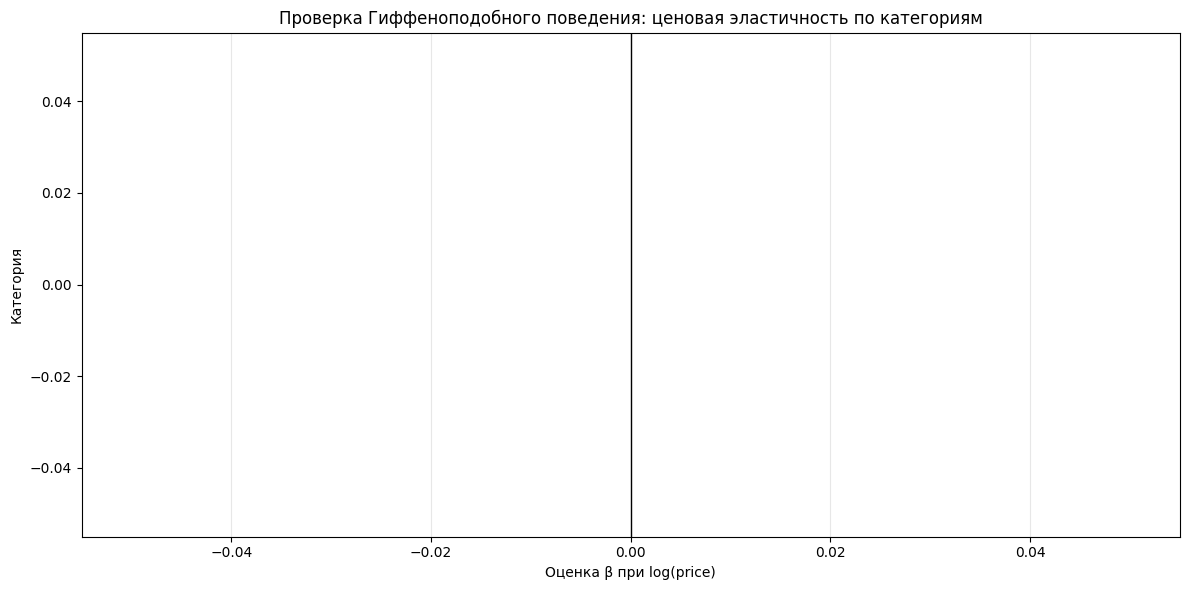

In [13]:
# ============================================================
# 4. Визуализация результатов
# ============================================================

import math
from textwrap import fill

# 4.1. Барчарт ценовой эластичности
plot_df = giffen_results.copy()
plot_df = plot_df.dropna(subset=["Ценовая эластичность β"])

plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if row["Ценовая эластичность β"] > 0 and row["p-value β"] <= ALPHA
    else "tab:orange" if row["Ценовая эластичность β"] > 0
    else "tab:blue"
    for _, row in plot_df.iterrows()
]

labels = [
    fill(name, width=28)
    for name in plot_df["Название группы"]
]

plt.barh(labels, plot_df["Ценовая эластичность β"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Проверка Гиффеноподобного поведения: ценовая эластичность по категориям")
plt.xlabel("Оценка β при log(price)")
plt.ylabel("Категория")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(GIFFEN_DIR / "ценовая_эластичность_по_категориям.png", dpi=160)
plt.show()


# 4.2. Scatter residual plot на одном холсте
if len(residual_plot_data) > 0:
    residual_df = pd.concat(residual_plot_data, ignore_index=True)

    groups = (
        residual_df[["product_group_code", "product_group_name"]]
        .drop_duplicates()
        .sort_values("product_group_name")
    )

    n_groups = len(groups)
    ncols = 2
    nrows = math.ceil(n_groups / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, groups.iterrows()):
        group_code = row["product_group_code"]
        group_name = row["product_group_name"]

        g = residual_df[residual_df["product_group_code"] == group_code].copy()

        ax.scatter(g["price_resid"], g["q_resid"], alpha=0.75)

        if len(g) >= 2:
            z = np.polyfit(g["price_resid"], g["q_resid"], 1)
            x_line = np.linspace(g["price_resid"].min(), g["price_resid"].max(), 50)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line, linewidth=2)

        ax.axhline(0, color="black", linewidth=0.8)
        ax.axvline(0, color="black", linewidth=0.8)

        metric_row = giffen_results[giffen_results["Код группы"] == group_code]
        if len(metric_row) > 0:
            beta = metric_row["Ценовая эластичность β"].iloc[0]
            pval = metric_row["p-value β"].iloc[0]
            ax.text(
                0.02,
                0.95,
                f"β = {beta:.3f}\np = {pval:.3f}",
                transform=ax.transAxes,
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round", alpha=0.15)
            )

        ax.set_title(fill(group_name, width=35))
        ax.set_xlabel("Остаток log(price) после контролей")
        ax.set_ylabel("Остаток log(quantity) после контролей")
        ax.grid(True, alpha=0.3)

    for j in range(n_groups, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "Partial regression: связь цены и объёма после контроля сезонности, тренда и шоков",
        fontsize=15
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(GIFFEN_DIR / "partial_regression_price_quantity.png", dpi=160)
    plt.show()

In [14]:
# ============================================================
# 5. Короткий текстовый вывод
# ============================================================

print("Итоги проверки на товары Гиффена")
print("=" * 60)

for _, row in giffen_results.iterrows():
    print(f"\n{row['Название группы']}")
    print(f"  β цена: {row['Ценовая эластичность β']:.4f}")
    print(f"  p-value β: {row['p-value β']:.4f}")

    if pd.notna(row["Доходная эластичность γ"]):
        print(f"  γ доход: {row['Доходная эластичность γ']:.4f}")
        print(f"  p-value γ: {row['p-value γ']:.4f}")
    else:
        print("  Доходная эластичность: не проверялась, нет переменной дохода")

    print(f"  Вывод: {row['Вывод']}")

print("\nФайлы сохранены в:", GIFFEN_DIR)

Итоги проверки на товары Гиффена

Хлеб, крупы, мука и макаронные изделия
  β цена: nan
  p-value β: nan
  Доходная эластичность: не проверялась, нет переменной дохода
  Вывод: Недостаточно данных для проверки

Молочная продукция и яйца
  β цена: nan
  p-value β: nan
  Доходная эластичность: не проверялась, нет переменной дохода
  Вывод: Недостаточно данных для проверки

Мясо, птица, рыба и колбасные изделия
  β цена: nan
  p-value β: nan
  Доходная эластичность: не проверялась, нет переменной дохода
  Вывод: Недостаточно данных для проверки

Овощи, фрукты и картофель
  β цена: nan
  p-value β: nan
  Доходная эластичность: не проверялась, нет переменной дохода
  Вывод: Недостаточно данных для проверки

Бакалея, масло, сахар, чай, соль
  β цена: nan
  p-value β: nan
  Доходная эластичность: не проверялась, нет переменной дохода
  Вывод: Недостаточно данных для проверки

Товары для дома, гигиены и бытовая химия
  β цена: nan
  p-value β: nan
  Доходная эластичность: не проверялась, нет пе

In [15]:
# ============================================================
# Устойчивая проверка категорий на Гиффеноподобное поведение
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from textwrap import fill
import math

OUT_DIR = Path("/content/drive/MyDrive/rostat/demand_forecast_2025")
GIFFEN_DIR = OUT_DIR / "giffen_test"
GIFFEN_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.10

# G11 исключаем: это услуги.
# G10 можно добавить отдельно, если хочешь тестировать топливо.
GIFFEN_TEST_GROUPS = ["G01", "G02", "G03", "G04", "G05", "G07", "G99"]

# ------------------------------------------------------------
# 1. Подготовка данных
# ------------------------------------------------------------

df = quarterly_data[
    quarterly_data["product_group_code"].isin(GIFFEN_TEST_GROUPS)
].copy()

df = df.sort_values(["product_group_code", "period_end"]).reset_index(drop=True)

def make_index_from_first_valid(x):
    x = x.astype(float)
    valid = x.dropna()
    if len(valid) == 0:
        return pd.Series(np.nan, index=x.index)
    base = valid.iloc[0]
    if pd.isna(base) or base == 0:
        return pd.Series(np.nan, index=x.index)
    return x / base * 100

# Цена с восстановленным 2021
if "price_index_filled" not in df.columns:
    df["price_index_filled"] = (
        df
        .groupby("product_group_code")["price_index"]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )

# Наблюдаемый физический proxy-объём
if "real_sales_proxy_index_filled" not in df.columns:
    df["real_sales_proxy_filled"] = (
        df["sales_index"] / df["price_index_filled"] * 100
    )

    df["real_sales_proxy_index_filled"] = (
        df
        .groupby("product_group_code")["real_sales_proxy_filled"]
        .transform(make_index_from_first_valid)
    )

df["q_obs_proxy"] = df["real_sales_proxy_index_filled"]

df["log_q"] = np.log(df["q_obs_proxy"].clip(lower=1e-6))
df["log_price"] = np.log((df["price_index_filled"] / 100).clip(lower=1e-6))

df["time_idx"] = df.groupby("product_group_code").cumcount()

# Event-флаги
if "shock_2022_q1" not in df.columns:
    df["shock_2022_q1"] = ((df["year"] == 2022) & (df["quarter"] == 1)).astype(int)

if "shock_2022_q2" not in df.columns:
    df["shock_2022_q2"] = ((df["year"] == 2022) & (df["quarter"] == 2)).astype(int)

if "shock_2022_h2" not in df.columns:
    df["shock_2022_h2"] = ((df["year"] == 2022) & (df["quarter"].isin([3, 4]))).astype(int)

if "post_2022" not in df.columns:
    df["post_2022"] = (df["period_end"] >= pd.Timestamp("2022-03-31")).astype(int)

# Дефицит запасов: используем только если stock_days_mean реально заполнен
if "stock_days_mean" in df.columns and df["stock_days_mean"].notna().sum() >= 20:
    pre_shock = df["year"].between(2017, 2021)

    normal_stock = (
        df.loc[pre_shock]
        .groupby("product_group_code")["stock_days_mean"]
        .median()
        .to_dict()
    )

    df["normal_stock_days"] = df["product_group_code"].map(normal_stock)
    df["stock_shortage"] = (
        df["normal_stock_days"] - df["stock_days_mean"]
    ).clip(lower=0)

    # Ключевое исправление: если stock_shortage NaN, считаем, что дефицит не наблюдался
    df["stock_shortage"] = df["stock_shortage"].fillna(0)
else:
    df["stock_shortage"] = 0.0

# Ищем переменную дохода, если ты её добавишь в датасет
possible_income_cols = [
    "real_income_index",
    "real_disposable_income_index",
    "income_index",
    "real_income",
    "real_wage_index",
]

income_col = None
for col in possible_income_cols:
    if col in df.columns and df[col].notna().sum() >= 20:
        income_col = col
        break

if income_col is not None:
    df["log_income"] = np.log(df[income_col].clip(lower=1e-6))
    print("Используется переменная дохода:", income_col)
else:
    print("Переменная дохода не найдена. Будет проверяться только положительная ценовая эластичность.")

# Диагностика покрытия
diagnostic = (
    df
    .groupby(["product_group_code", "product_group_name"])
    .agg(
        n_rows=("period_end", "count"),
        log_q_non_null=("log_q", lambda x: x.notna().sum()),
        log_price_non_null=("log_price", lambda x: x.notna().sum()),
        stock_shortage_non_null=("stock_shortage", lambda x: x.notna().sum()),
        q_obs_non_null=("q_obs_proxy", lambda x: x.notna().sum()),
        price_non_null=("price_index_filled", lambda x: x.notna().sum()),
    )
    .reset_index()
)

display(diagnostic)

Переменная дохода не найдена. Будет проверяться только положительная ценовая эластичность.


,product_group_code,product_group_name,n_rows,log_q_non_null,log_price_non_null,stock_shortage_non_null,q_obs_non_null,price_non_null
0,G01,"Хлеб, крупы, мука и макаронные изделия",40,36,40,40,36,40
1,G02,Молочная продукция и яйца,40,36,40,40,36,40
2,G03,"Мясо, птица, рыба и колбасные изделия",40,36,40,40,36,40
3,G04,"Овощи, фрукты и картофель",40,36,40,40,36,40
4,G05,"Бакалея, масло, сахар, чай, соль",40,36,40,40,36,40
5,G07,"Товары для дома, гигиены и бытовая химия",40,36,40,40,36,40
6,G99,Прочее,40,36,40,40,36,40


In [16]:
# ============================================================
# 2. Регрессионный тест
# ============================================================

giffen_rows = []
residual_plot_data = []

for group_code, g in df.groupby("product_group_code"):
    g = g.copy().sort_values("period_end")

    # Минимально обязательные переменные
    model_data = g[
        [
            "log_q",
            "log_price",
            "quarter",
            "time_idx",
            "stock_shortage",
            "shock_2022_q1",
            "shock_2022_q2",
            "shock_2022_h2",
            "post_2022",
        ] + (["log_income"] if income_col is not None else [])
    ].copy()

    # Обязательные для теста: только log_q и log_price
    model_data = model_data.dropna(subset=["log_q", "log_price"])

    # Остальные контролы заполняем нулями, чтобы они не убивали выборку
    fill_zero_cols = [
        "stock_shortage",
        "shock_2022_q1",
        "shock_2022_q2",
        "shock_2022_h2",
        "post_2022",
    ]
    for col in fill_zero_cols:
        if col in model_data.columns:
            model_data[col] = model_data[col].fillna(0)

    if income_col is not None and "log_income" in model_data.columns:
        # Доход не заполняем нулём: если по нему мало данных, просто убираем из модели
        if model_data["log_income"].notna().sum() < 20:
            model_data = model_data.drop(columns=["log_income"])
            use_income = False
        else:
            model_data = model_data.dropna(subset=["log_income"])
            use_income = True
    else:
        use_income = False

    if len(model_data) < 20:
        giffen_rows.append({
            "Код группы": group_code,
            "Название группы": g["product_group_name"].iloc[0],
            "Статус": "Недостаточно данных",
            "Число наблюдений": len(model_data),
            "Ценовая эластичность β": np.nan,
            "p-value β": np.nan,
            "Доходная эластичность γ": np.nan,
            "p-value γ": np.nan,
            "R²": np.nan,
            "Spearman price-volume": np.nan,
            "Spearman p-value": np.nan,
            "Вывод": "Недостаточно данных для проверки",
        })
        continue

    X_cols = [
        "log_price",
        "time_idx",
        "stock_shortage",
        "shock_2022_q1",
        "shock_2022_q2",
        "shock_2022_h2",
        "post_2022",
    ]

    if use_income:
        X_cols.append("log_income")

    X = model_data[X_cols].copy()

    # Убираем константные контролы, чтобы не ломать OLS
    non_constant_cols = []
    for col in X.columns:
        if X[col].nunique(dropna=True) > 1:
            non_constant_cols.append(col)

    X = X[non_constant_cols]

    quarter_dummies = pd.get_dummies(
        model_data["quarter"].astype(int),
        prefix="Q",
        drop_first=True
    )

    X = pd.concat([X, quarter_dummies], axis=1)

    # Только числовые типы
    X = X.astype(float)
    X = sm.add_constant(X, has_constant="add")

    y = model_data["log_q"].astype(float)

    result = sm.OLS(y, X).fit(cov_type="HC3")

    beta_price = result.params.get("log_price", np.nan)
    beta_price_pvalue = result.pvalues.get("log_price", np.nan)

    if use_income:
        gamma_income = result.params.get("log_income", np.nan)
        gamma_income_pvalue = result.pvalues.get("log_income", np.nan)
    else:
        gamma_income = np.nan
        gamma_income_pvalue = np.nan

    corr_data = model_data[["log_price", "log_q"]].dropna()
    if len(corr_data) >= 5:
        spearman_corr, spearman_p = spearmanr(corr_data["log_price"], corr_data["log_q"])
    else:
        spearman_corr, spearman_p = np.nan, np.nan

    price_positive_significant = (
        pd.notna(beta_price)
        and beta_price > 0
        and pd.notna(beta_price_pvalue)
        and beta_price_pvalue <= ALPHA
    )

    price_positive_weak = (
        pd.notna(beta_price)
        and beta_price > 0
        and not price_positive_significant
    )

    if use_income:
        income_negative = pd.notna(gamma_income) and gamma_income < 0
        income_negative_significant = (
            income_negative
            and pd.notna(gamma_income_pvalue)
            and gamma_income_pvalue <= ALPHA
        )

        if price_positive_significant and income_negative_significant:
            conclusion = "Сильный кандидат в товары Гиффена"
            status = "strong_giffen_candidate"
        elif price_positive_significant and income_negative:
            conclusion = "Кандидат: цена положительная, доход отрицательный, но доход слабозначим"
            status = "possible_giffen_candidate"
        elif price_positive_significant:
            conclusion = "Гиффеноподобное поведение по цене, но доходный критерий не подтверждён"
            status = "price_giffen_like_only"
        elif price_positive_weak:
            conclusion = "Слабый положительный ценовой эффект, статистически не подтверждён"
            status = "weak_positive_price_effect"
        else:
            conclusion = "Признаков товара Гиффена не найдено"
            status = "not_giffen"
    else:
        if price_positive_significant:
            conclusion = "Гиффеноподобное поведение по цене; доходный критерий не проверен"
            status = "price_giffen_like_only"
        elif price_positive_weak:
            conclusion = "Слабый положительный ценовой эффект, статистически не подтверждён"
            status = "weak_positive_price_effect"
        else:
            conclusion = "Признаков товара Гиффена не найдено"
            status = "not_giffen"

    giffen_rows.append({
        "Код группы": group_code,
        "Название группы": g["product_group_name"].iloc[0],
        "Статус": status,
        "Число наблюдений": len(model_data),
        "Ценовая эластичность β": beta_price,
        "p-value β": beta_price_pvalue,
        "Доходная эластичность γ": gamma_income,
        "p-value γ": gamma_income_pvalue,
        "R²": result.rsquared,
        "Spearman price-volume": spearman_corr,
        "Spearman p-value": spearman_p,
        "Вывод": conclusion,
    })

    # Partial regression data
    controls_cols = [c for c in X.columns if c not in ["const", "log_price"]]

    if len(controls_cols) > 0:
        X_controls = sm.add_constant(X[controls_cols], has_constant="add")
        y_resid = sm.OLS(y, X_controls).fit().resid
        price_resid = sm.OLS(model_data["log_price"].astype(float), X_controls).fit().resid
    else:
        y_resid = y - y.mean()
        price_resid = model_data["log_price"].astype(float) - model_data["log_price"].astype(float).mean()

    tmp = pd.DataFrame({
        "product_group_code": group_code,
        "product_group_name": g["product_group_name"].iloc[0],
        "price_resid": price_resid,
        "q_resid": y_resid,
    })

    residual_plot_data.append(tmp)

giffen_results = pd.DataFrame(giffen_rows)

status_order = {
    "strong_giffen_candidate": 1,
    "possible_giffen_candidate": 2,
    "price_giffen_like_only": 3,
    "weak_positive_price_effect": 4,
    "not_giffen": 5,
    "Недостаточно данных": 6,
}

giffen_results["status_order"] = giffen_results["Статус"].map(status_order).fillna(99)

giffen_results = giffen_results.sort_values(
    by=["status_order", "Ценовая эластичность β"],
    ascending=[True, False]
).drop(columns=["status_order"])

display(giffen_results)

giffen_results.to_csv(
    GIFFEN_DIR / "проверка_товаров_гиффена_по_категориям.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:", GIFFEN_DIR / "проверка_товаров_гиффена_по_категориям.csv")

,Код группы,Название группы,Статус,Число наблюдений,Ценовая эластичность β,p-value β,Доходная эластичность γ,p-value γ,R²,Spearman price-volume,Spearman p-value,Вывод
2,G03,"Мясо, птица, рыба и колбасные изделия",weak_positive_price_effect,36,0.128254,7.501148e-01,NaN,NaN,0.827234,0.232690,0.172034,"Слабый положительный ценовой эффект, статистич..."
5,G07,"Товары для дома, гигиены и бытовая химия",weak_positive_price_effect,36,0.104944,8.442203e-01,NaN,NaN,0.908394,0.510682,0.001460,"Слабый положительный ценовой эффект, статистич..."
1,G02,Молочная продукция и яйца,not_giffen,36,-0.057813,8.174970e-01,NaN,NaN,0.733084,0.072072,0.676155,Признаков товара Гиффена не найдено
4,G05,"Бакалея, масло, сахар, чай, соль",not_giffen,36,-0.736999,1.543308e-07,NaN,NaN,0.858463,-0.204646,0.231203,Признаков товара Гиффена не найдено
3,G04,"Овощи, фрукты и картофель",not_giffen,36,-0.922871,4.942931e-10,NaN,NaN,0.929760,-0.439382,0.007337,Признаков товара Гиффена не найдено
0,G01,"Хлеб, крупы, мука и макаронные изделия",not_giffen,36,-1.084642,1.155344e-15,NaN,NaN,0.894292,-0.106306,0.537182,Признаков товара Гиффена не найдено
6,G99,Прочее,not_giffen,36,-1.477829,8.596342e-06,NaN,NaN,0.845257,0.524487,0.001025,Признаков товара Гиффена не найдено


Сохранено: /content/drive/MyDrive/rostat/demand_forecast_2025/giffen_test/проверка_товаров_гиффена_по_категориям.csv


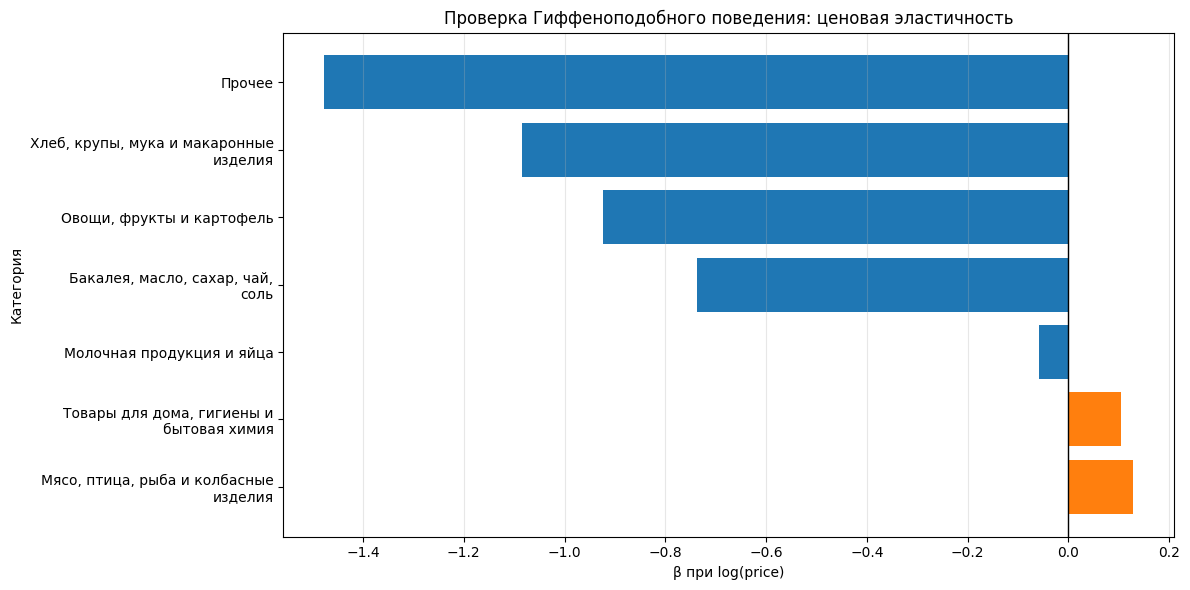

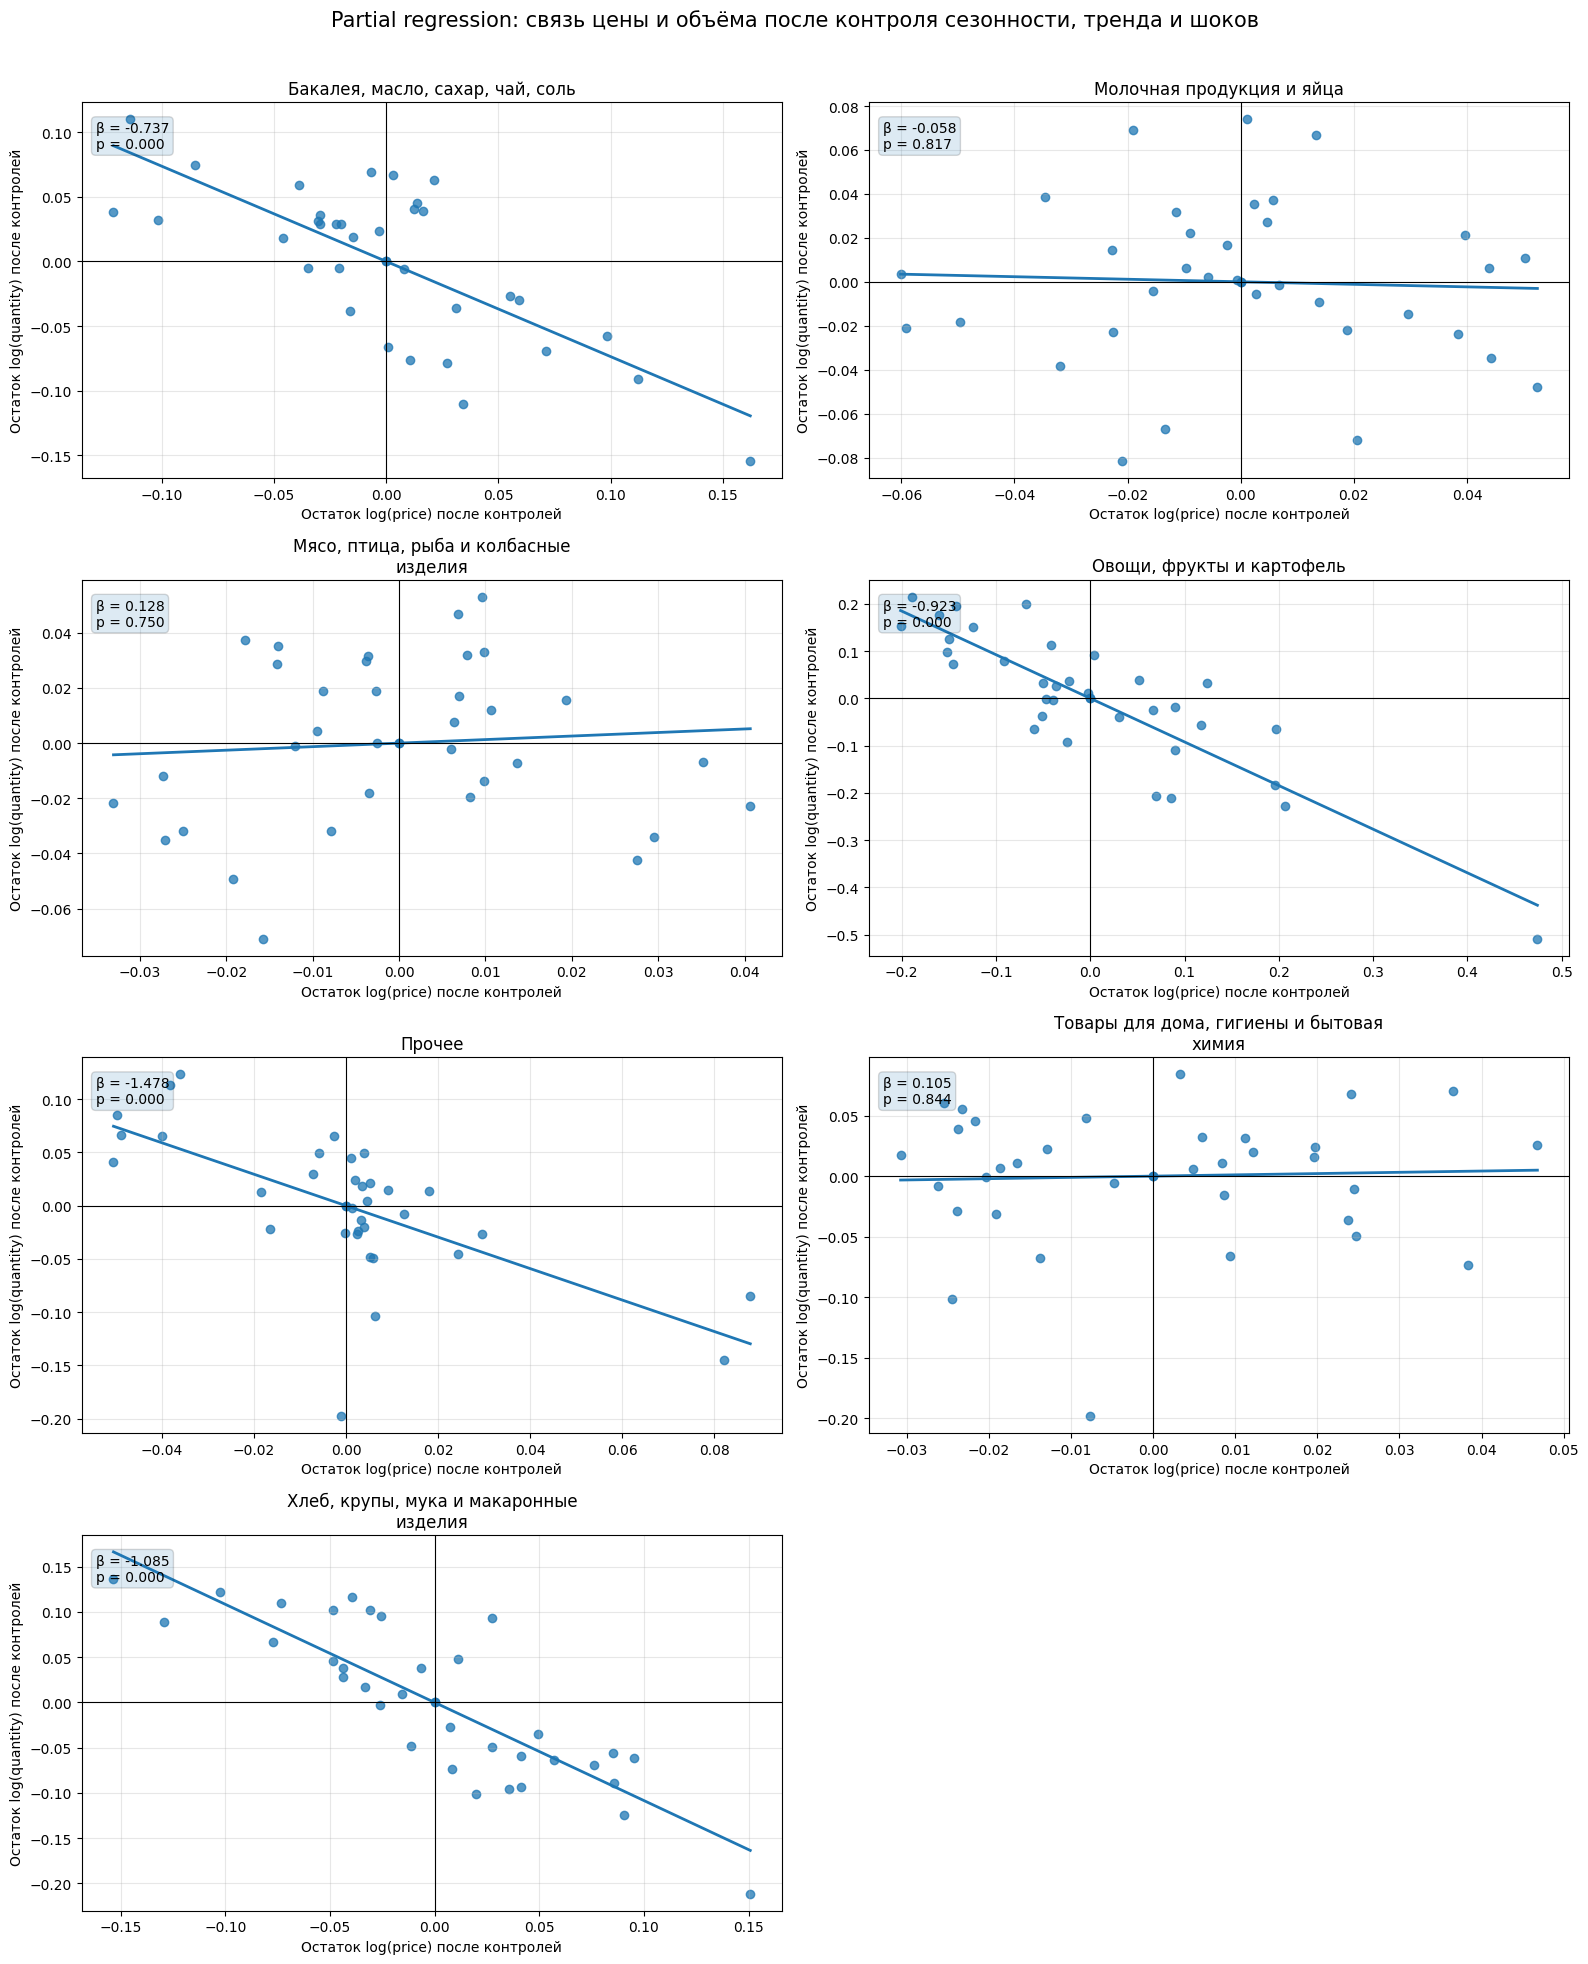

In [17]:
# ============================================================
# 3. Визуализация
# ============================================================

plot_df = giffen_results.copy()
plot_df = plot_df.dropna(subset=["Ценовая эластичность β"])

if len(plot_df) > 0:
    plt.figure(figsize=(12, 6))

    colors = [
        "tab:red" if row["Ценовая эластичность β"] > 0 and row["p-value β"] <= ALPHA
        else "tab:orange" if row["Ценовая эластичность β"] > 0
        else "tab:blue"
        for _, row in plot_df.iterrows()
    ]

    labels = [fill(name, width=30) for name in plot_df["Название группы"]]

    plt.barh(labels, plot_df["Ценовая эластичность β"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Проверка Гиффеноподобного поведения: ценовая эластичность")
    plt.xlabel("β при log(price)")
    plt.ylabel("Категория")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    plt.savefig(GIFFEN_DIR / "ценовая_эластичность_по_категориям.png", dpi=160)
    plt.show()

if len(residual_plot_data) > 0:
    residual_df = pd.concat(residual_plot_data, ignore_index=True)

    groups = (
        residual_df[["product_group_code", "product_group_name"]]
        .drop_duplicates()
        .sort_values("product_group_name")
    )

    n_groups = len(groups)
    ncols = 2
    nrows = math.ceil(n_groups / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, groups.iterrows()):
        group_code = row["product_group_code"]
        group_name = row["product_group_name"]

        g = residual_df[residual_df["product_group_code"] == group_code].copy()

        ax.scatter(g["price_resid"], g["q_resid"], alpha=0.75)

        if len(g) >= 2:
            z = np.polyfit(g["price_resid"], g["q_resid"], 1)
            x_line = np.linspace(g["price_resid"].min(), g["price_resid"].max(), 50)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line, linewidth=2)

        ax.axhline(0, color="black", linewidth=0.8)
        ax.axvline(0, color="black", linewidth=0.8)

        metric_row = giffen_results[giffen_results["Код группы"] == group_code]
        if len(metric_row) > 0 and pd.notna(metric_row["Ценовая эластичность β"].iloc[0]):
            beta = metric_row["Ценовая эластичность β"].iloc[0]
            pval = metric_row["p-value β"].iloc[0]
            ax.text(
                0.02,
                0.95,
                f"β = {beta:.3f}\np = {pval:.3f}",
                transform=ax.transAxes,
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round", alpha=0.15)
            )

        ax.set_title(fill(group_name, width=35))
        ax.set_xlabel("Остаток log(price) после контролей")
        ax.set_ylabel("Остаток log(quantity) после контролей")
        ax.grid(True, alpha=0.3)

    for j in range(n_groups, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "Partial regression: связь цены и объёма после контроля сезонности, тренда и шоков",
        fontsize=15
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(GIFFEN_DIR / "partial_regression_price_quantity.png", dpi=160)
    plt.show()

In [18]:
# ============================================================
# Разбивка групп на отдельные товары
# Создаёт product_quarterly_data.csv
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd

BASE_DIR = Path("/content/drive/MyDrive/rostat")
OUT_DIR = BASE_DIR / "product_level_dataset"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Helpers
# ------------------------------------------------------------

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower().replace("ё", "е")
    x = re.sub(r"\s+", " ", x)
    return x

def find_file(patterns, dirs):
    for d in dirs:
        d = Path(d)
        if not d.exists():
            continue
        for pattern in patterns:
            files = sorted(d.glob(pattern))
            if files:
                return files[0]
    return None

def make_index_from_first_valid(x):
    x = x.astype(float)
    valid = x.dropna()
    if len(valid) == 0:
        return pd.Series(np.nan, index=x.index)
    base = valid.iloc[0]
    if pd.isna(base) or base == 0:
        return pd.Series(np.nan, index=x.index)
    return x / base * 100

def detect_col(df, candidates, required=True):
    cols_norm = {normalize_text(c): c for c in df.columns}
    for cand in candidates:
        cand_norm = normalize_text(cand)
        if cand_norm in cols_norm:
            return cols_norm[cand_norm]

    for col in df.columns:
        col_norm = normalize_text(col)
        for cand in candidates:
            if normalize_text(cand) in col_norm:
                return col

    if required:
        raise ValueError(f"Не найдена колонка из кандидатов: {candidates}\nКолонки: {df.columns.tolist()}")
    return None

In [19]:
# ------------------------------------------------------------
# 2. Загружаем mapping товаров к группам
# ------------------------------------------------------------

mapping_path = BASE_DIR / "processed_sales" / "sales_to_price_mapping.csv"

if not mapping_path.exists():
    raise FileNotFoundError(
        f"Не найден mapping: {mapping_path}\n"
        "Нужен файл sales_to_price_mapping.csv, где товары сопоставлены с группами."
    )

mapping = pd.read_csv(mapping_path)

print("Mapping columns:")
print(mapping.columns.tolist())

# Нормализуем возможные названия колонок
sales_product_code_col = detect_col(mapping, ["sales_product_code", "код товара продаж"], required=False)
sales_product_name_col = detect_col(mapping, ["sales_product_name", "sales_product_raw", "товар"], required=True)
group_code_col = detect_col(mapping, ["product_group_code", "код группы"], required=True)
group_name_col = detect_col(mapping, ["product_group_name", "название группы"], required=True)

mapping = mapping.copy()

if sales_product_code_col is None:
    mapping["sales_product_code_tmp"] = mapping[sales_product_name_col].map(normalize_text)
    sales_product_code_col = "sales_product_code_tmp"

mapping["sales_product_key"] = mapping[sales_product_code_col].astype(str)
mapping["sales_product_name_clean"] = mapping[sales_product_name_col]
mapping["product_group_code"] = mapping[group_code_col]
mapping["product_group_name"] = mapping[group_name_col]

mapping_small = (
    mapping[
        [
            "sales_product_key",
            "sales_product_name_clean",
            "product_group_code",
            "product_group_name",
        ]
    ]
    .drop_duplicates()
)

display(mapping_small.head(20))

FileNotFoundError: Не найден mapping: /content/drive/MyDrive/rostat/processed_sales/sales_to_price_mapping.csv
Нужен файл sales_to_price_mapping.csv, где товары сопоставлены с группами.

In [20]:
# ============================================================
# Mapping товаров к группам без sales_to_price_mapping.csv
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd

BASE_DIR = Path("/content/drive/MyDrive/rostat")
OUT_DIR = BASE_DIR / "product_level_dataset"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower().replace("ё", "е")
    x = re.sub(r"\s+", " ", x)
    return x

def map_product_to_group(product_name):
    s = normalize_text(product_name)

    # G01 Хлеб, крупы, мука, макароны
    if any(k in s for k in [
        "хлеб", "булоч", "мука", "круп", "греч", "рис",
        "пшено", "макарон", "вермишель", "рожки", "овсян"
    ]):
        return "G01", "Хлеб, крупы, мука и макаронные изделия"

    # G02 Молочная продукция и яйца
    if any(k in s for k in [
        "молоко", "сыр", "творог", "сметан", "кефир",
        "йогурт", "масло сливоч", "яйц", "яйцо"
    ]):
        return "G02", "Молочная продукция и яйца"

    # G03 Мясо, птица, рыба, колбаса
    if any(k in s for k in [
        "говядин", "свинин", "баранин", "мяс", "птиц", "кур",
        "колбас", "сосиск", "сардель", "рыб", "сельд", "фарш",
        "консервы мяс", "консервы рыб"
    ]):
        return "G03", "Мясо, птица, рыба и колбасные изделия"

    # G04 Овощи, фрукты, картофель
    if any(k in s for k in [
        "картоф", "капуст", "морков", "лук", "свекл",
        "огур", "помид", "томат", "овощ", "яблок", "груш",
        "банан", "апельс", "лимон", "фрукт", "виноград"
    ]):
        return "G04", "Овощи, фрукты и картофель"

    # G05 Бакалея, масло, сахар, чай, соль
    if any(k in s for k in [
        "сахар", "соль", "чай", "кофе", "масло подсолнеч",
        "масло раститель", "маргарин", "печенье", "шоколад",
        "конфет", "какао"
    ]):
        return "G05", "Бакалея, масло, сахар, чай, соль"

    # G07 Дом, гигиена, бытовая химия
    if any(k in s for k in [
        "мыло", "порошок", "моющ", "чистящ", "зубная паст",
        "шампун", "бумага туалет", "подгуз", "гигиен",
        "стираль", "бытовая хим"
    ]):
        return "G07", "Товары для дома, гигиены и бытовая химия"

    # G10 Топливо
    if any(k in s for k in [
        "бензин", "дизель", "топливо", "газ мотор"
    ]):
        return "G10", "Топливо и транспортные товары"

    # G11 Услуги
    if any(k in s for k in [
        "услуг", "электроэнерг", "водоснаб", "водоотвед",
        "отоплен", "горячая вода", "проезд"
    ]):
        return "G11", "Услуги"

    return "G99", "Прочее"

In [21]:
# ============================================================
# Поиск файла с товарными продажами
# ============================================================

def find_file_by_keywords(base_dir, keywords, suffixes=(".csv", ".xls", ".xlsx")):
    candidates = []

    for p in base_dir.rglob("*"):
        if not p.is_file():
            continue
        if p.suffix.lower() not in suffixes:
            continue

        name = normalize_text(p.name)

        score = 0
        for kw in keywords:
            if normalize_text(kw) in name:
                score += 1

        if score > 0:
            candidates.append((score, p))

    candidates = sorted(candidates, key=lambda x: (-x[0], str(x[1])))
    return [p for score, p in candidates]

sales_candidates = find_file_by_keywords(
    BASE_DIR,
    keywords=[
        "sales",
        "rozn",
        "розн",
        "57701",
        "57699",
        "prodazh",
        "продаж",
        "dynamics",
    ]
)

print("Кандидаты на файл продаж:")
for p in sales_candidates[:30]:
    print(p)

Кандидаты на файл продаж:


In [22]:
for p in sales_candidates[:5]:
    print("\nFILE:", p)
    try:
        if p.suffix.lower() == ".csv":
            display(pd.read_csv(p).head())
        else:
            xl = pd.ExcelFile(p)
            print("Sheets:", xl.sheet_names)
            display(pd.read_excel(p, sheet_name=xl.sheet_names[0], header=None).head(10))
    except Exception as e:
        print("ERROR:", e)